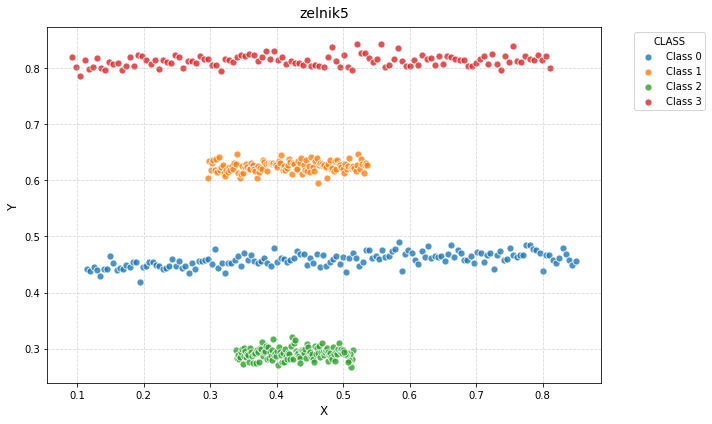

In [6]:
import matplotlib.pyplot as plt
from scipy.io import arff
import pandas as pd

# 사용자가 지정한 데이터셋 경로
file_path = '/home/junhyung/study/Data_Analysis_with_CKKS/Cluster/DBSCAN_CKKS/desilo/dataset/Other_cluster/zelnik5.arff'

try:
    # 1. ARFF 파일 로드 및 DataFrame 변환
    data, meta = arff.loadarff(file_path)
    df = pd.DataFrame(data)
    
    # [주의] scipy.io.arff로 읽어올 때 클래스 값(Nominal)이 바이트 문자열(b'0', b'1' 등)로 
    # 반환되는 경우가 많습니다. 이를 일반 문자열로 디코딩해줍니다.
    if df['CLASS'].dtype == object:
        df['CLASS'] = df['CLASS'].str.decode('utf-8')
        
    # 정렬을 위해 숫자형으로 변환 (0, 1, 2, 3, 4)
    df['CLASS'] = df['CLASS'].astype(int)
    
    # 2. 시각화 설정
    plt.figure(figsize=(10, 6))
    
    # 존재하는 클래스 목록을 추출하여 오름차순 정렬
    classes = sorted(df['CLASS'].unique())
    
    # 3. 클래스별로 분리하여 산점도(Scatter) 그리기
    for cls in classes:
        subset = df[df['CLASS'] == cls]
        plt.scatter(
            subset['x'], 
            subset['y'], 
            label=f'Class {cls}', 
            alpha=0.8,          # 투명도 조절로 겹치는 점 확인
            edgecolors='w',     # 점 테두리를 흰색으로 하여 가독성 증가
            s=50                # 점 크기
        )
        
    # 4. 그래프 꾸미기 및 출력
    plt.title('zelnik5', fontsize=14, pad=10)
    plt.xlabel('X', fontsize=12)
    plt.ylabel('Y', fontsize=12)
    plt.legend(title='CLASS', bbox_to_anchor=(1.05, 1), loc='upper left') # 범례를 그래프 바깥으로
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout() # 여백 자동 조절
    
    plt.show()

except FileNotFoundError:
    print(f"Error: 파일을 찾을 수 없습니다. 경로를 다시 한 번 확인해주세요:\n{file_path}")
except ImportError as e:
    print(f"Error: 필수 라이브러리가 설치되어 있지 않습니다. 터미널에서 다음을 실행하세요.\n pip install pandas scipy matplotlib")